# MeRN Quick Start Tutorial

## Metabolic Representation Net (MeRN)

Single-cell RNA-seq data provides rich information about gene expression across thousands of cells, but interpreting **cellular metabolism** from transcriptomic data alone is challenging. Many metabolic processes are coordinated across genes and reactions, making them difficult to capture with standard dimensionality reduction methods.

**Metabolic Representation Net (MeRN)** is a graph-guided variational autoencoder designed to infer metabolic state from single-cell transcriptomic data.

Standard VAEs such as **scVI** learn low-dimensional latent representations of cells and decode them to gene-level parameters using flexible neural networks. While these models capture complex transcriptional structure, the latent dimensions are not explicitly linked to metabolic processes.

MeRN introduces a **metabolic prior** by leveraging a metabolic reaction graph, where:

- **nodes** represent metabolic reactions  
- **edges** connect reactions that share metabolites

A graph VAE learns embeddings of this reaction network, and the cell-level latent space is decomposed into two components:

• **Metabolic variation** — variation explained by metabolic reactions  
• **Background variation** — non-metabolic transcriptional variation

This structure links latent dimensions to **reaction activity and enzyme-coding genes**, enabling interpretable metabolic representations.

In this notebook we demonstrate how to:

- fit MeRN to scRNA-seq data  
- extract metabolic and background embeddings  
- analyze metabolic differences across cell populations  
- investigate reaction- and pathway-level metabolic signals

As an example, we apply MeRN to a **single-cell dictionary of cytokine responses in immune cells** generated by  
[Cui et al., Nature 2024](https://www.nature.com/articles/s41586-023-06816-9).

In [1]:
# relevant imports
import scvi
from scvi.train._callbacks import SaveCheckpoint
import anndata as ad
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import mern_support
import pickle, pathlib
import copy, pickle, pathlib
from matplotlib.patches import Patch
import scipy.sparse as sp
from scipy.stats import binomtest
import seaborn as sns
from sklearn.linear_model import HuberRegressor
import requests

/Users/adelinac/opt/anaconda3/envs/mern_2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Initialization
Load the cytokine dictionary subsample, annotate genes with metabolic pathway metadata, and build the reaction graph. Then select highly variable metabolic and background genes (after filtering genes seen in at least 100 cells) to define the feature set for modeling.

In [2]:
rna = ad.read_h5ad('data/cytokine_dict_subsample.h5ad.gz')
sc.pp.filter_genes(rna, min_cells=100) # filter genes based on number of cells or counts

In [3]:
dataset = mern_support.KeggKGMLMetabolicDataset(species='mouse', capitalize=False)
dataset.add_module_info(rna)
met_g = dataset.metabolic_topology(rna, self_loops=False)
dataset.add_rxn_module_info(rna, met_g)
rxn_genes = dataset.get_rxn_genes_all()

/Users/adelinac/opt/anaconda3/envs/mern_2/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:178: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


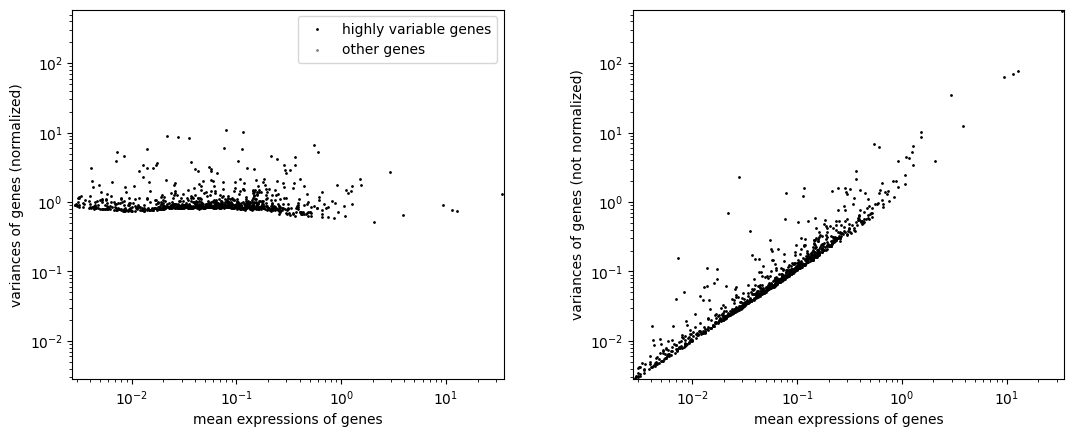

/Users/adelinac/opt/anaconda3/envs/mern_2/lib/python3.10/site-packages/scanpy/preprocessing/_highly_variable_genes.py:178: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


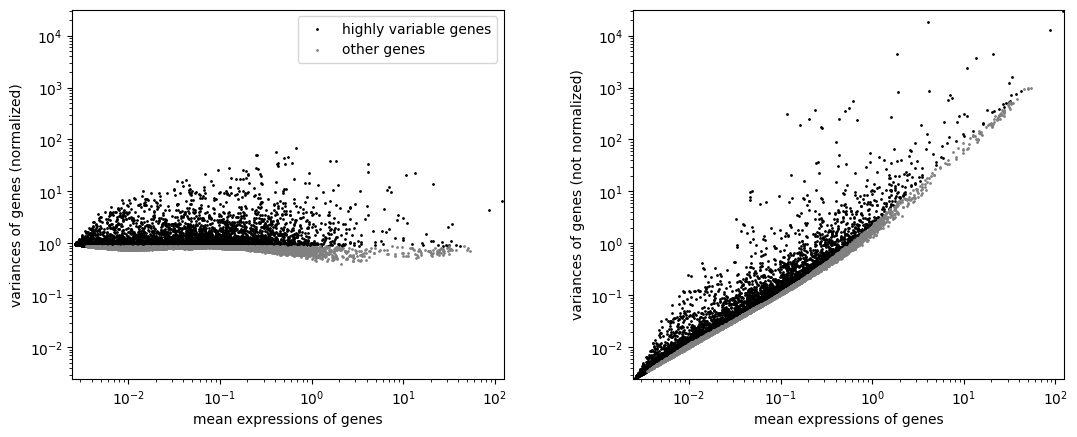

In [4]:
temp_rna = rna[:, rna.var['Metabolic Gene'] == 'Metabolic']
sc.pp.highly_variable_genes(temp_rna, n_top_genes=1000, flavor="seurat_v3", layer="counts")
sc.pl.highly_variable_genes(temp_rna, log=True)
met_hvgs = list(temp_rna.var_names[temp_rna.var["highly_variable"]])
temp_rna = rna[:, rna.var['Metabolic Gene'] == 'Non-metabolic']
sc.pp.highly_variable_genes(temp_rna, n_top_genes=5000, flavor="seurat_v3", layer="counts")
sc.pl.highly_variable_genes(temp_rna, log=True)
back_hvgs = list(temp_rna.var_names[temp_rna.var["highly_variable"]])
rna.var['highly_variable_metabolic'] = [True if gene in met_hvgs else False for gene in rna.var.index]
rna.var['highly_variable_background'] = [True if gene in back_hvgs else False for gene in rna.var.index]

In [5]:
features_to_use = list(rna.var_names[rna.var["highly_variable_metabolic"] | rna.var["highly_variable_background"]])
features_to_use.sort()
rna = rna[:, features_to_use].copy()

print(rna)
print(rna.var['Metabolic Gene'].value_counts())

AnnData object with n_obs × n_vars = 38670 × 5926
    obs: 'biosample_id', 'donor_id', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'channel', 'hashtag', 'channel_hashtag', 'rep', 'cyt', 'cyt_display', 'cyt_rep', 'percent_mito', 'RNA_snn_res_1_5', 'subcluster', 'cluster_manual', 'celltype', 'celltype_display', 'celltype_unsubsetdata', 'species', 'species__ontology_label', 'disease', 'disease__ontology_label', 'organ', 'organ__ontology_label', 'library_preparation_protocol', 'library_preparation_protocol__ontology_label', 'sex'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'Gene Reactions', 'Metabolic Gene', 'highly_variable_metabolic', 'highly_variable_background'
    uns: 'hvg', 'Reaction Info'
    layers: 'counts'
Metabolic Gene
Non-metabolic    5000
Metabolic         926
Name: count, dtype: int64


### Create and fit MeRN model
You can either train a fresh MeRN model (or load a saved checkpoint). When training, set loss weights and KL schedules, configure checkpointing, and fit the model with early stopping. After training, reload the best checkpoint, save the training history, and plot key loss curves to verify convergence. If not training, load the pretrained model and history, then re-instantiate the MeRN model with the chosen architecture.

In [6]:
train_new_model = False

In [7]:
# training
if train_new_model:
    # set a place you want model checkpointng saved
    data_dir = 'models'

    # some weights i've been using, feel free to play around, but most don't make a huge difference

    plan_kwargs={
        "max_kl_weight": 0.001,  # KL divergence weight from args
        "graph_kl_weight": 0.1,
        "data_elbo_weight": 1.0,  # Keep data reconstruction weight
        "graph_elbo_weight": 0.2,  # Graph reconstruction weight from args
        "rxn_genes_weight": 0.5,  # Reaction-to-genes weight from args
        "background_to_metabolic_weight": 30000,  # Background-to-metabolic weight from args
        "lr": 0.002,
        "n_steps_kl_warmup": 0,  # KL warmup epochs from args
        "n_epochs_kl_warmup": None
    }

    # if using batch, set batch_key and encode_covariates to True
    checkpointing = SaveCheckpoint(
        dirpath=f'{data_dir}/scvi_log_3', monitor="validation_loss", load_best_on_end=False, check_nan_gradients=False
    )
    scvi.external.mern.MERN.setup_anndata(rna, layer='counts', batch_key=None)
    # encode covariate since decoder doesn't use batch currently
    mern = scvi.external.mern.MERN(rna, met_g, rxn_genes, n_hidden=256, n_layers=2, n_metabolic_dim=25, n_background_dim=15, encode_covariates=False, strict_met_back_separation=True, rxn_genes_bias=True)
    mern.train(accelerator="mps", max_epochs=400, early_stopping=True, early_stopping_monitor="validation_loss", plan_kwargs=plan_kwargs, callbacks = [checkpointing])

    best_mern = scvi.external.mern.MERN.load(checkpointing.best_model_path, rna, accelerator='mps')

    history = copy.deepcopy(mern.history)
    pathlib.Path("runs_mern_history_11_20/mern_history.pkl").write_bytes(pickle.dumps(history))
else:
    # load in saved model
    model = scvi.external.mern.MERN.load("/Users/adelinac/Documents/Berkeley/Research/Wagner/models/scvi_log_2/epoch=350-step=95472-validation_loss=0.37840643525123596", rna, accelerator='mps')
    history_path = pathlib.Path("run_mern_history_11_20/mern_history.pkl")
    with history_path.open("rb") as fh:
        history = pickle.load(fh)

INFO     File                                                                                                      
         /Users/adelinac/Documents/Berkeley/Research/Wagner/models/scvi_log_2/epoch=350-step=95472-validation_loss=
         0.37840643525123596/model.pt already downloaded                                                           


/Users/adelinac/Documents/Berkeley/Research/Wagner/scvi-tools-mern/src/scvi/model/base/_base_model.py:796: UserWarning: `accelerator` has been set to `mps`. Please note that not all PyTorch/Jax operations are supported with this backend. as a result, some models might be slower and less accurate than usuall. Please verify your analysis!Refer to https://github.com/pytorch/pytorch/issues/77764 for more details.
  _, _, device = parse_device_args(


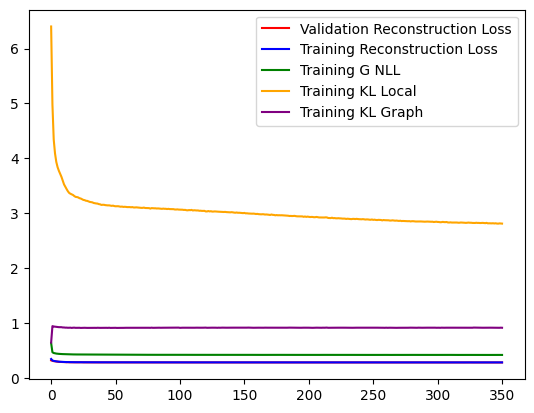

In [8]:
# check losses
plt.plot(history['reconstruction_loss_validation'], color='red', label='Validation Reconstruction Loss')
plt.plot(history['reconstruction_loss_train'], color='blue', label='Training Reconstruction Loss')
plt.plot(history['g_nll_train'], color='green', label='Training G NLL')
plt.plot(history['kl_local_train'], color='orange', label='Training KL Local')
plt.plot(history['kl_v_train'], color='purple', label='Training KL Graph')
plt.legend()
plt.show()

In [9]:
mern = scvi.external.mern.MERN(rna, met_g, rxn_genes, n_hidden=256, n_layers=2, n_metabolic_dim=25, n_background_dim=15, encode_covariates=False, strict_met_back_separation=True, rxn_genes_bias=True)

In [10]:
rna.obsm['X_mern_metabolic'], rna.obsm['X_mern_background'], graph_embedding = model.get_latent_representation()
graph_embedding = pd.DataFrame(graph_embedding, index=mern.vertex_names_ordered)

## Metabolic vs. Non Metabolic (Background) Embedding
MeRN produces two latent embeddings for every cell:

**Background embedding**

This embedding captures **general transcriptional variation**, including:

- cell type identity
- cytokine responses
- transcriptional activation programs

It behaves similarly to embeddings learned by standard single-cell models.

**### **Metabolic embedding**

This embedding captures **variation explained by metabolic reactions**.

Cells that appear similar transcriptionally may still differ in:

- metabolic pathway usage
- enzyme activity
- reaction flux patterns

The metabolic embedding highlights these differences.

By comparing the two embeddings we can determine whether differences between cells are:

- primarily transcriptional
- primarily metabolic

### Embedding Clustering and Analysis

/var/folders/rw/56p7h0px0xl82phr2ps3qy8c0000gn/T/ipykernel_31338/3184218085.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(rna, neighbors_key='met_neighbors', key_added='met_leiden', resolution=res)


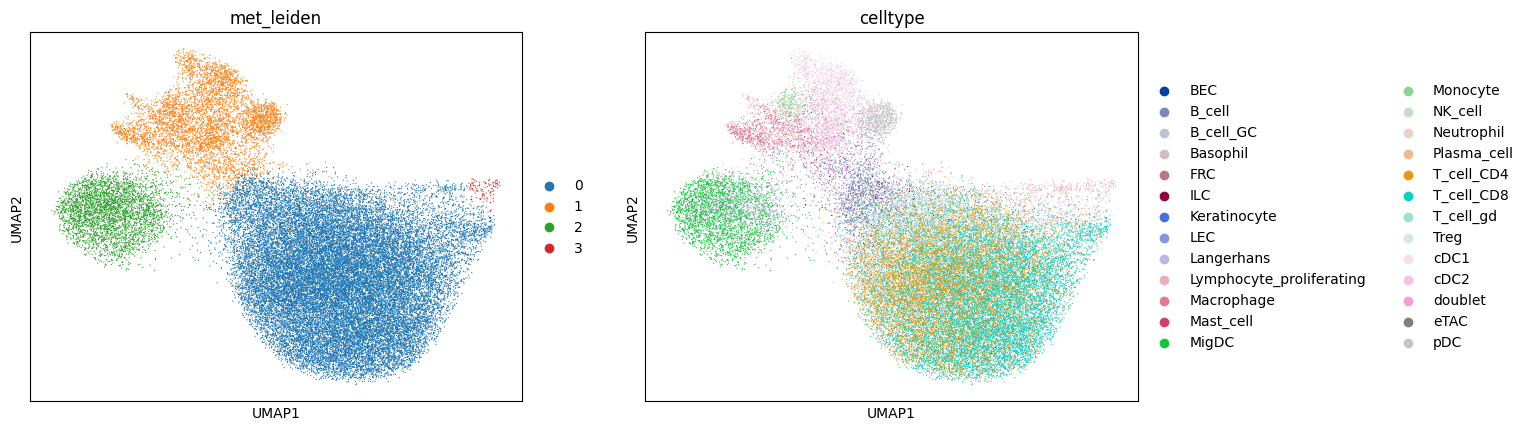

In [ ]:
# metabolic embedding
sc.pp.neighbors(rna, use_rep='X_mern_metabolic', key_added='met_neighbors')
sc.tl.umap(rna, neighbors_key='met_neighbors')
sc.tl.leiden(rna, neighbors_key='met_neighbors', key_added='met_leiden', resolution=0.3)
sc.pl.umap(rna, color=['met_leiden', 'celltype'], neighbors_key='met_neighbors')

In [ ]:
cluster_key = "met_leiden"

cluster_labels = {
    "0": "T Cells",
    "1": "Non Migratory Myeloid Cells",
    "2": "Migratory Myeloid Cells",
    "3": "Proliferating Cells",
}

rna.obs["met_leiden_label"] = (
    rna.obs[cluster_key].astype(str).map(cluster_labels)
)

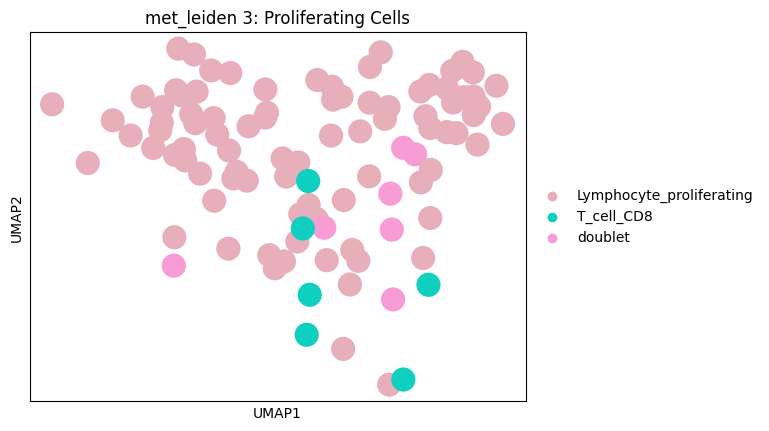

In [14]:
cluster_id = "3"
rna_c = rna[rna.obs['met_leiden'] == cluster_id].copy()

props = rna_c.obs['celltype'].value_counts(normalize=True)
major_types = props[props >= 0.05].index
rna_c_major = rna_c[rna_c.obs['celltype'].isin(major_types)].copy()

cluster_name = cluster_labels.get(cluster_id, "Unknown Cluster")

sc.pl.umap(
    rna_c_major,
    color='celltype',
    title=f"met_leiden {cluster_id}: {cluster_name}"
)

We notice that in cluster 3, there seems to be many proliferating cells (this is verifiable by looking at gene Mki67's presence in these cells as Mki67 is known to be a robust marker for cellular proliferation).

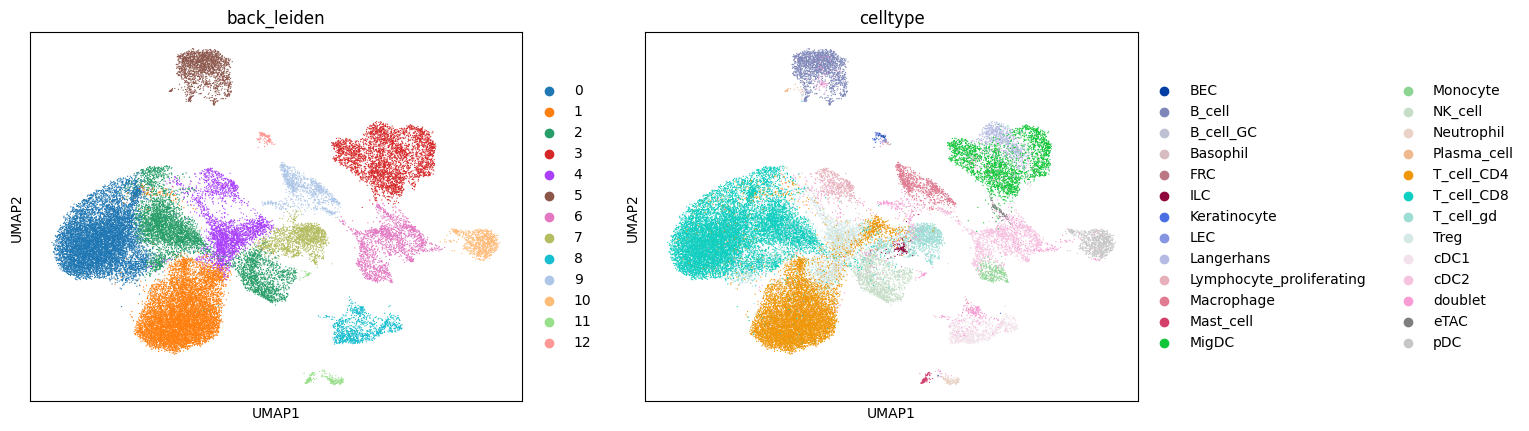

In [ ]:
# background embedding
sc.pp.neighbors(rna, use_rep='X_mern_background', key_added='back_neighbors')
sc.tl.umap(rna, neighbors_key='back_neighbors')
sc.tl.leiden(rna, neighbors_key='back_neighbors', key_added='back_leiden', resolution=0.3)
sc.pl.umap(rna, color=['back_leiden', 'celltype'], neighbors_key='back_neighbors') # see how cell identity + cytokines distribute

In [19]:
original_rna = rna.copy()

### Metabolic vs Background Embedding Comparison via Residuals
To quantify metabolic specialization we compare distances between cells in the two embeddings.

For each cell we compute:

- distance to neighbors in the **background embedding**
- distance to neighbors in the **metabolic embedding**

We then compute a **residual score**:

residual = metabolic_distance − background_distance

Interpretation:

• **Positive residual** means cells are more different metabolically than transcriptionally and suggests metabolic specialization

• **Negative residual** means cells are transcriptionally distinct but metabolically similar

This analysis helps identify populations whose **functional differences are driven by metabolism rather than general transcriptional changes**.

In [20]:
rna = original_rna.copy()

In [21]:
def add_back_neighbor_distance_columns(
    adata,
    back_dist_key="back_neighbors_distances",
    met_emb_key="X_mern_metabolic",
    x_col="back_neighbor_dist_back",
    y_col="back_neighbor_dist_met",
):
    D_back = adata.obsp[back_dist_key]
    if not sp.isspmatrix_csr(D_back):
        D_back = D_back.tocsr()

    X_met = adata.obsm[met_emb_key]
    n = adata.n_obs

    x = np.full(n, np.nan, dtype=float)  # background-space neighbor distance
    y = np.full(n, np.nan, dtype=float)  # metabolic-space distance to same neighbors

    for i in range(n):
        start, end = D_back.indptr[i], D_back.indptr[i + 1]
        nbr_idx = D_back.indices[start:end]
        d_back = D_back.data[start:end]

        # remove self-neighbor if present
        mask = nbr_idx != i
        nbr_idx = nbr_idx[mask]
        d_back = d_back[mask]

        if nbr_idx.size == 0:
            continue

        # mean background neighbor distance (already in graph)
        x[i] = d_back.mean()

        # mean metabolic distance to the same neighbors
        d_met = np.linalg.norm(X_met[nbr_idx] - X_met[i], axis=1)
        y[i] = d_met.mean()

    adata.obs[x_col] = x
    adata.obs[y_col] = y

# run
add_back_neighbor_distance_columns(rna)

# quick check
rna.obs[["back_neighbor_dist_back", "back_neighbor_dist_met"]].head()

,back_neighbor_dist_back,back_neighbor_dist_met
AAGAACAGTACCAATC-06,1.401034,4.901672
GTAGGTTTCTCTATAC-28,1.095088,3.711914
CGATCGGTCTGTCTCG-37,1.678025,4.942881
CTCGAGGTCGTAACTG-08,0.743443,4.568394
CTATAGGGTCTAGATC-45,0.865367,4.865516


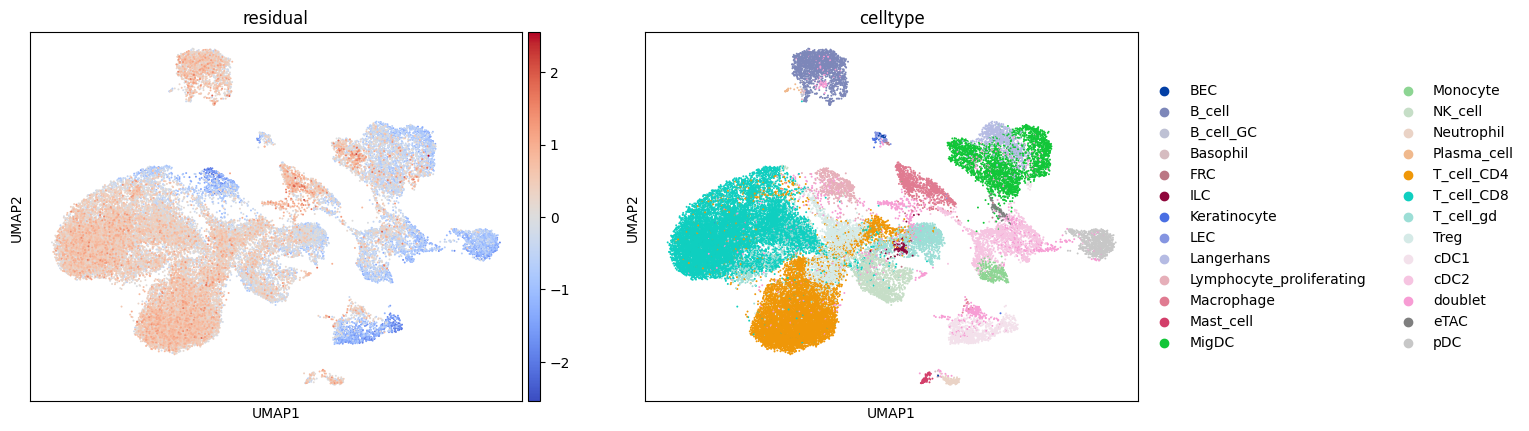

In [23]:
# UMAP colored by residual
sc.pl.umap(
    rna,
    color=["residual", "celltype"],
    neighbors_key="met_neighbors",
    cmap="coolwarm",      # blue low, red high
    vcenter=0,            # center colormap at zero residual
    size=8
)

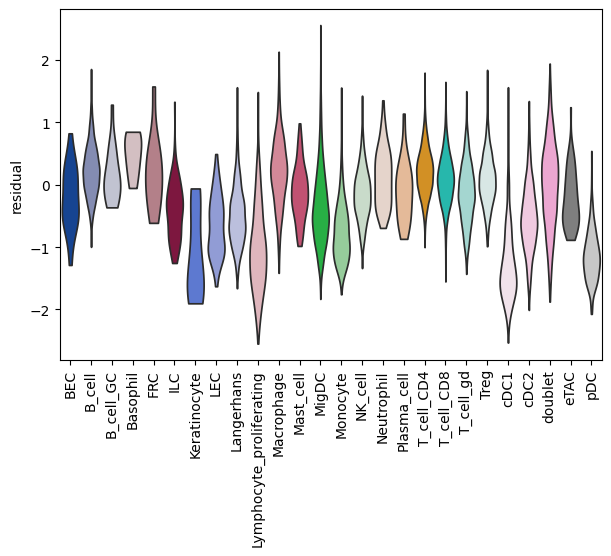

In [24]:
# Violin by cell type
sc.pl.violin(
    rna,
    keys="residual",
    groupby="celltype",   # or "celltype"
    rotation=90,
    stripplot=False
)

## Enzyme Activity

### Reaction-level metabolic activity across immune populations
One advantage of MeRN is that it provides **reaction-level metabolic signals** for each cell in addition to the metabolic embedding. These signals reflect the inferred activity of metabolic reactions based on the expression of their associated enzyme-coding genes and their relationships within the metabolic network.

Here we extract the model's inferred **reaction activity matrix**, where:

- rows correspond to **cells**
- columns correspond to **metabolic reactions** (identified by KEGG reaction IDs)

For each reaction, we compute the **average inferred activity within each cluster**. To emphasize relative differences between cell populations, each reaction is standardized across clusters (z-scored). This normalization highlights reactions that are selectively higher or lower in specific groups rather than those that are globally high across all cells.

Finally, we visualize these standardized reaction activities using a clustermap. Reactions are hierarchically clustered to reveal groups of reactions with similar activity patterns across the immune populations.

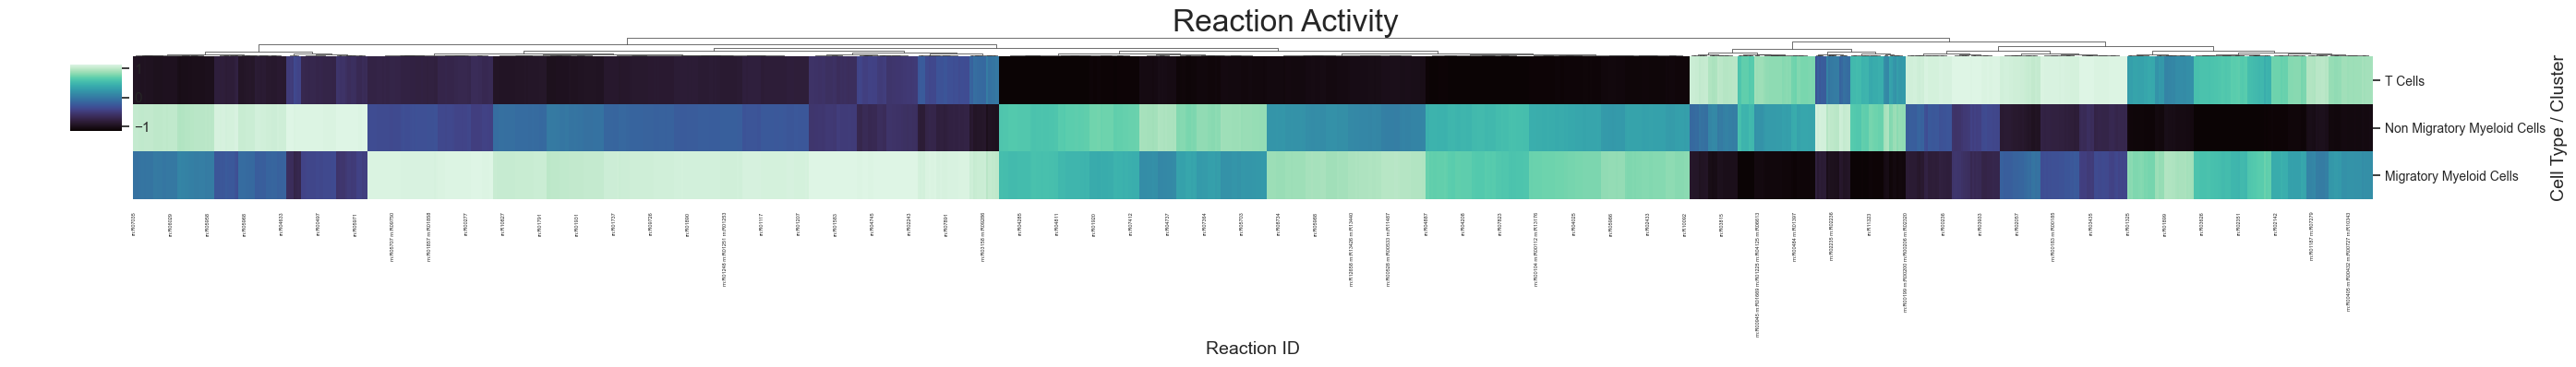

In [25]:
decoding = model.get_decoding()
enz_activity = decoding['enzyme_activity']
rxn_info = rna.uns["Reaction Info"]
rxn_ids = rxn_info.index.to_list()
enz_activity = np.asarray(enz_activity, dtype=float)

sns.set_theme(style="white", font_scale=1.0)

enzyme_acts = pd.DataFrame(
    enz_activity,
    index=rna.obs_names,
    columns=rxn_ids,
)

cluster_key = "met_leiden"
keep_clusters = ["0", "1", "2"]

cluster_series = rna.obs[cluster_key].astype(str)
keep_cells = rna.obs_names[cluster_series.isin(keep_clusters)]

enzyme_acts_sub = enzyme_acts.loc[keep_cells].copy()
cluster_series_sub = cluster_series.loc[keep_cells].copy()

cluster_means = enzyme_acts_sub.groupby(cluster_series_sub).mean().T
cluster_means = cluster_means[keep_clusters]
cluster_means.columns = [cluster_labels[c] for c in cluster_means.columns]

cluster_means = cluster_means.loc[cluster_means.std(axis=1) > 0].copy()

plot_data = cluster_means.sub(cluster_means.mean(axis=1), axis=0)
plot_data = plot_data.div(cluster_means.std(axis=1), axis=0)

plot_data.index = plot_data.index.astype(str)

g = sns.clustermap(
    plot_data.T,
    cmap="mako",
    center=0,
    row_cluster=False,
    col_cluster=True,
    xticklabels=20,
    yticklabels=True,
    figsize=(28, 6),
    dendrogram_ratio=(0.05, 0.12),
    cbar_pos=(0.03, 0.8, 0.02, 0.12),
)

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=4)
plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=10)

g.ax_heatmap.set_xlabel("Reaction ID", fontsize=14)
g.ax_heatmap.set_ylabel("Cell Type / Cluster", fontsize=14)
g.fig.suptitle("Reaction Activity", fontsize=24, y=1.02)

plt.show()


### Pathway-level metabolic analysis

While reaction-level signals provide detailed information, metabolic reactions typically operate within larger **metabolic pathways**. To obtain a more interpretable view of metabolic programs, we aggregate reaction activity into pathway-level scores.

Using the inferred reaction activity matrix from MeRN, we compute **pathway scores** by combining the activity of reactions belonging to each metabolic pathway. This produces a pathway-by-cell matrix summarizing the activity of major metabolic processes.

Next, we identify pathways that differ between metabolic clusters using a **Wilcoxon rank-sum test**. For each cluster, we compare cells within that cluster to all other cells to identify pathways that are significantly enriched or depleted.

In parallel, we also perform the same statistical test at the **reaction level**, which allows us to identify individual reactions driving pathway differences.

To ensure that the pathway analysis focuses on biologically meaningful pathways, we apply several filters:

- restrict to pathways present in the KEGG mouse metabolic database  
- remove very general or global metabolic pathways  
- require that pathways contain a sufficient number of reactions

After filtering, we identify the **top pathways with the strongest effect sizes** for each cluster. These pathways highlight the major metabolic programs that distinguish the immune populations in this dataset.

In [26]:
enzyme_acts = pd.DataFrame(
    enz_activity,
    index=rna.obs_names,
    columns=rxn_ids,
)

cluster_enz_act_mean = enzyme_acts.groupby(rna.obs['met_leiden']).mean()
pathway_scores, pathway_rxns, pathway_names = mern_support.calculate_pathway_scores(enzyme_acts, rna.uns['Reaction Info'])

rxn_de_df_infos = {}
enrich_dfs = {}
for cluster in rna.obs['met_leiden'].unique():
    up_cells = rna[rna.obs['met_leiden']==cluster,:].obs_names
    down_cells = rna[rna.obs['met_leiden']!=cluster,:].obs_names
    enrich_df = mern_support.wilcoxon_test(pathway_scores, up_cells, down_cells)
    rxn_de_df = mern_support.wilcoxon_test(enzyme_acts.T, up_cells, down_cells)
    rxn_de_df['-log10(adj_pval)'] = -np.log10(rxn_de_df['adjusted_pval'])
    temp = rna.uns['Reaction Info'].copy()
    rxn_de_df_info = temp.join(rxn_de_df)
    rxn_de_df_info['edge_size'] = [3 if p < 0.05 else 2 for p in rxn_de_df_info['adjusted_pval']]
    rxn_de_df_infos[cluster] = rxn_de_df_info
    enrich_dfs[cluster] = enrich_df

for key in rxn_de_df_infos.keys():
    print(f'Cluster {key}:')
    print(rxn_de_df_infos[key].sort_values(by='cohens_d', ascending=False).head(50)['Rxn Name'].values)

enrich_df_concat = pd.concat({f"cluster_{k}": v for k, v in enrich_dfs.items()}, axis=1)
enrich_df_concat.columns = [f"{lvl0}_{lvl1}" for lvl0, lvl1 in enrich_df_concat.columns]

url = "https://rest.kegg.jp/list/pathway/mmu"
response = requests.get(url)
pathway_data = response.text

mouse_pathways = []
for line in pathway_data.strip().split('\n'):
    if '\t' in line:
        path_id, full_name = line.split('\t')
        mouse_pathways.append(path_id)
mouse_pathways = [name.replace('mmu', 'rn') for name in mouse_pathways]

keep_pathways = []
names = []
for pathway in enrich_df_concat.index:
    in_mouse = True if pathway in mouse_pathways else False
    not_general = True if not pathway.startswith('rn01') else False
    meets_cutoff = True if len(pathway_rxns[pathway]) > 10 else False
    if in_mouse and not_general and meets_cutoff:
        keep_pathways.append(pathway)
        names.append(pathway_names[pathway])
keep_pathways
enrich_df_concat = enrich_df_concat.loc[keep_pathways]
enrich_df_concat['Pathway Name'] = names
enrich_df_concat.index = enrich_df_concat['Pathway Name']

top_pathways = []
for cluster in range(3):
    temp_path = enrich_df_concat.sort_values(by=f'cluster_{cluster}_cohens_d', ascending=False).head(5)['Pathway Name'].values
    top_pathways+=list(temp_path)

/var/folders/rw/56p7h0px0xl82phr2ps3qy8c0000gn/T/ipykernel_31338/3206955298.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_enz_act_mean = enzyme_acts.groupby(rna.obs['met_leiden']).mean()
/Users/adelinac/opt/anaconda3/envs/mern_2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/adelinac/opt/anaconda3/envs/mern_2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/adelinac/opt/anaconda3/envs/mern_2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs,

Cluster 0:
['AMP aminohydrolase'
 'acetyl-CoA:oxaloacetate C-acetyltransferase (thioester-hydrolysing);acetyl-CoA:oxaloacetate C-acetyltransferase [(pro-S)-carboxymethyl-forming, ADP-phosphorylating]'
 'CTP:phosphatidate cytidyltransferase' 'IMP:NAD+ oxidoreductase'
 '1,2-diacyl-sn-glycerol 3-phosphate phosphohydrolase;ATP:1,2-diacylglycerol 3-phosphotransferase;CTP:1,2-diacyl-sn-glycerol 3-phosphotransferase'
 'CDP-diacylglycerol:myo-inositol 3-phosphatidyltransferase'
 "adenosine 3',5'-phosphate 5'-nucleotidohydrolase"
 'pyruvate:NAD+ 2-oxidoreductase (CoA-acetylating);;acetyl-CoA:formate C-acetyltransferase;pyruvate:ferredoxin 2-oxidoreductase (CoA-acetylating);pyruvate:flavodoxin 2-oxidoreductase (CoA-acetylating)'
 'ADP phosphohydrolase;ATP:AMP phosphotransferase'
 'IMP:diphosphate phospho-D-ribosyltransferase'
 'IMP 1,2-hydrolase (decyclizing)'
 "inosine 5'-monophosphate phosphohydrolase;ATP:inosine 5'-phosphotransferase"
 'ATP:1D-myo-inositol-1,4,5-trisphosphate 3-phosphotransfe

### Visualizing pathway enrichment across metabolic clusters

To summarize the pathway analysis, we visualize the enrichment effect sizes (Cohen’s d) for each pathway across the metabolic clusters.

Each entry in this matrix represents how strongly a pathway is enriched in a given cluster relative to the other cells. Larger values indicate stronger pathway activity in that cluster.

We then visualize these effect sizes using a clustermap, which groups pathways with similar enrichment patterns across cell populations. This helps reveal coordinated metabolic programs that distinguish the immune populations.

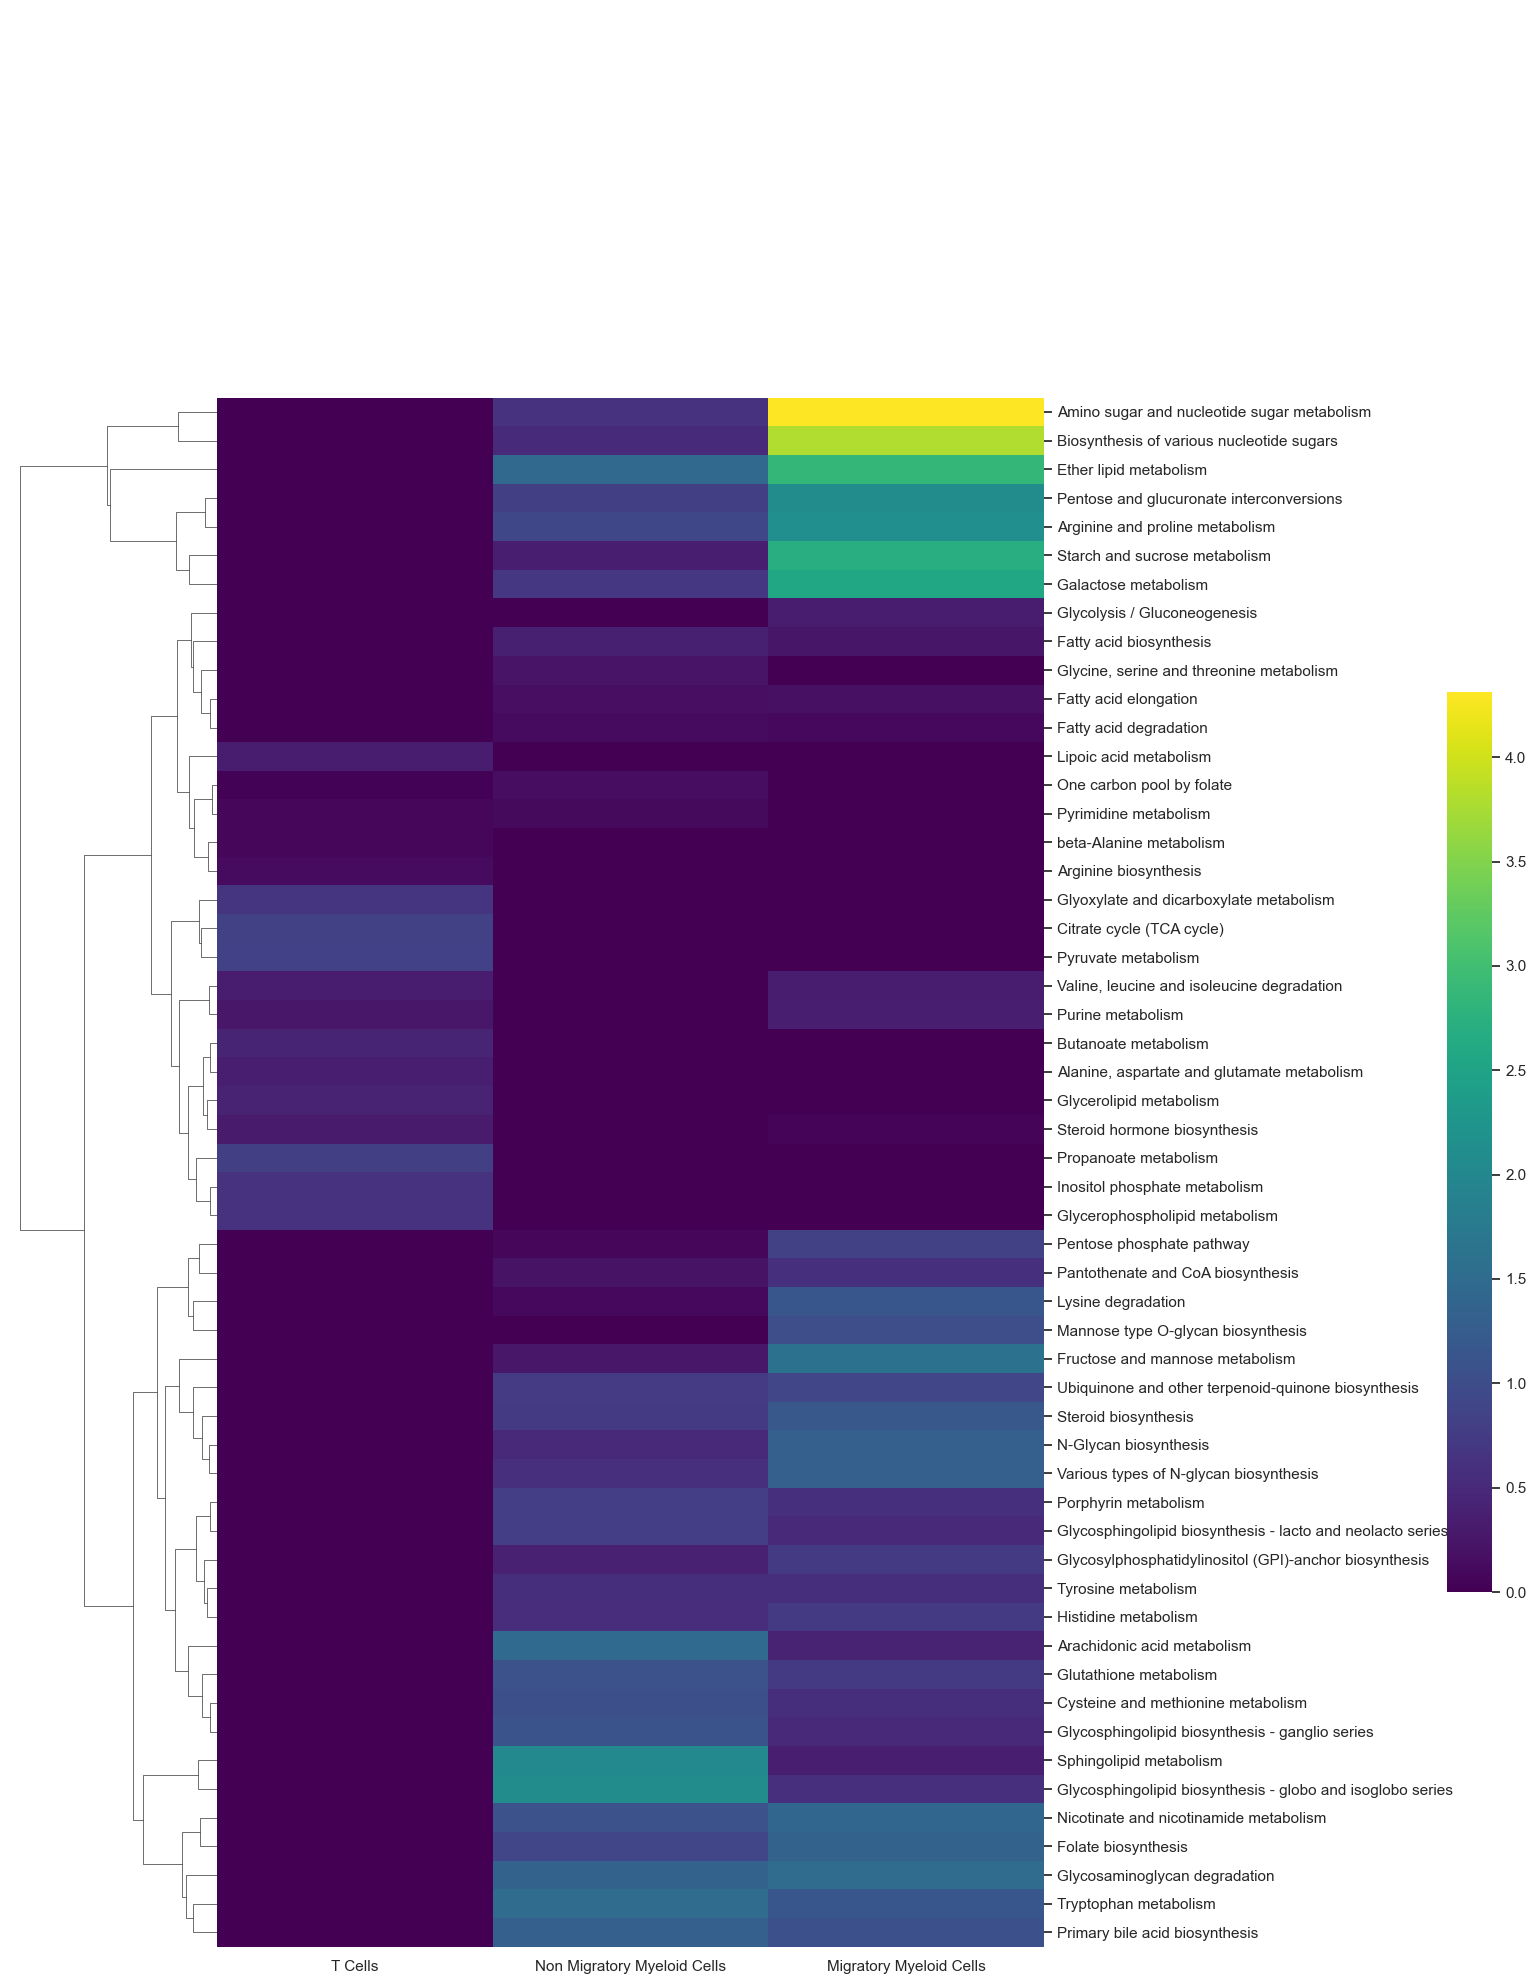

In [27]:
cluster_ids = [0, 1, 2]

temp = enrich_df_concat[[f"cluster_{i}_cohens_d" for i in cluster_ids]].copy()
pval_mat = enrich_df_concat[[f"cluster_{i}_adjusted_pval" for i in cluster_ids]].copy()

new_cols = [cluster_labels.get(str(i), f"Cluster {i}") for i in cluster_ids]
temp.columns = new_cols
pval_mat.columns = new_cols

g = sns.clustermap(
    temp,
    cmap="viridis",
    col_cluster=False,
    figsize=(15, 20),
    vmin=0
)

g.cax.set_position([.97, .2, .03, .45])

To focus on the most informative results, we restrict the visualization to the **top enriched pathways** identified earlier.  
We also annotate statistical significance using adjusted p-values, allowing pathways that show **significant enrichment differences across clusters** to be highlighted in the heatmap.

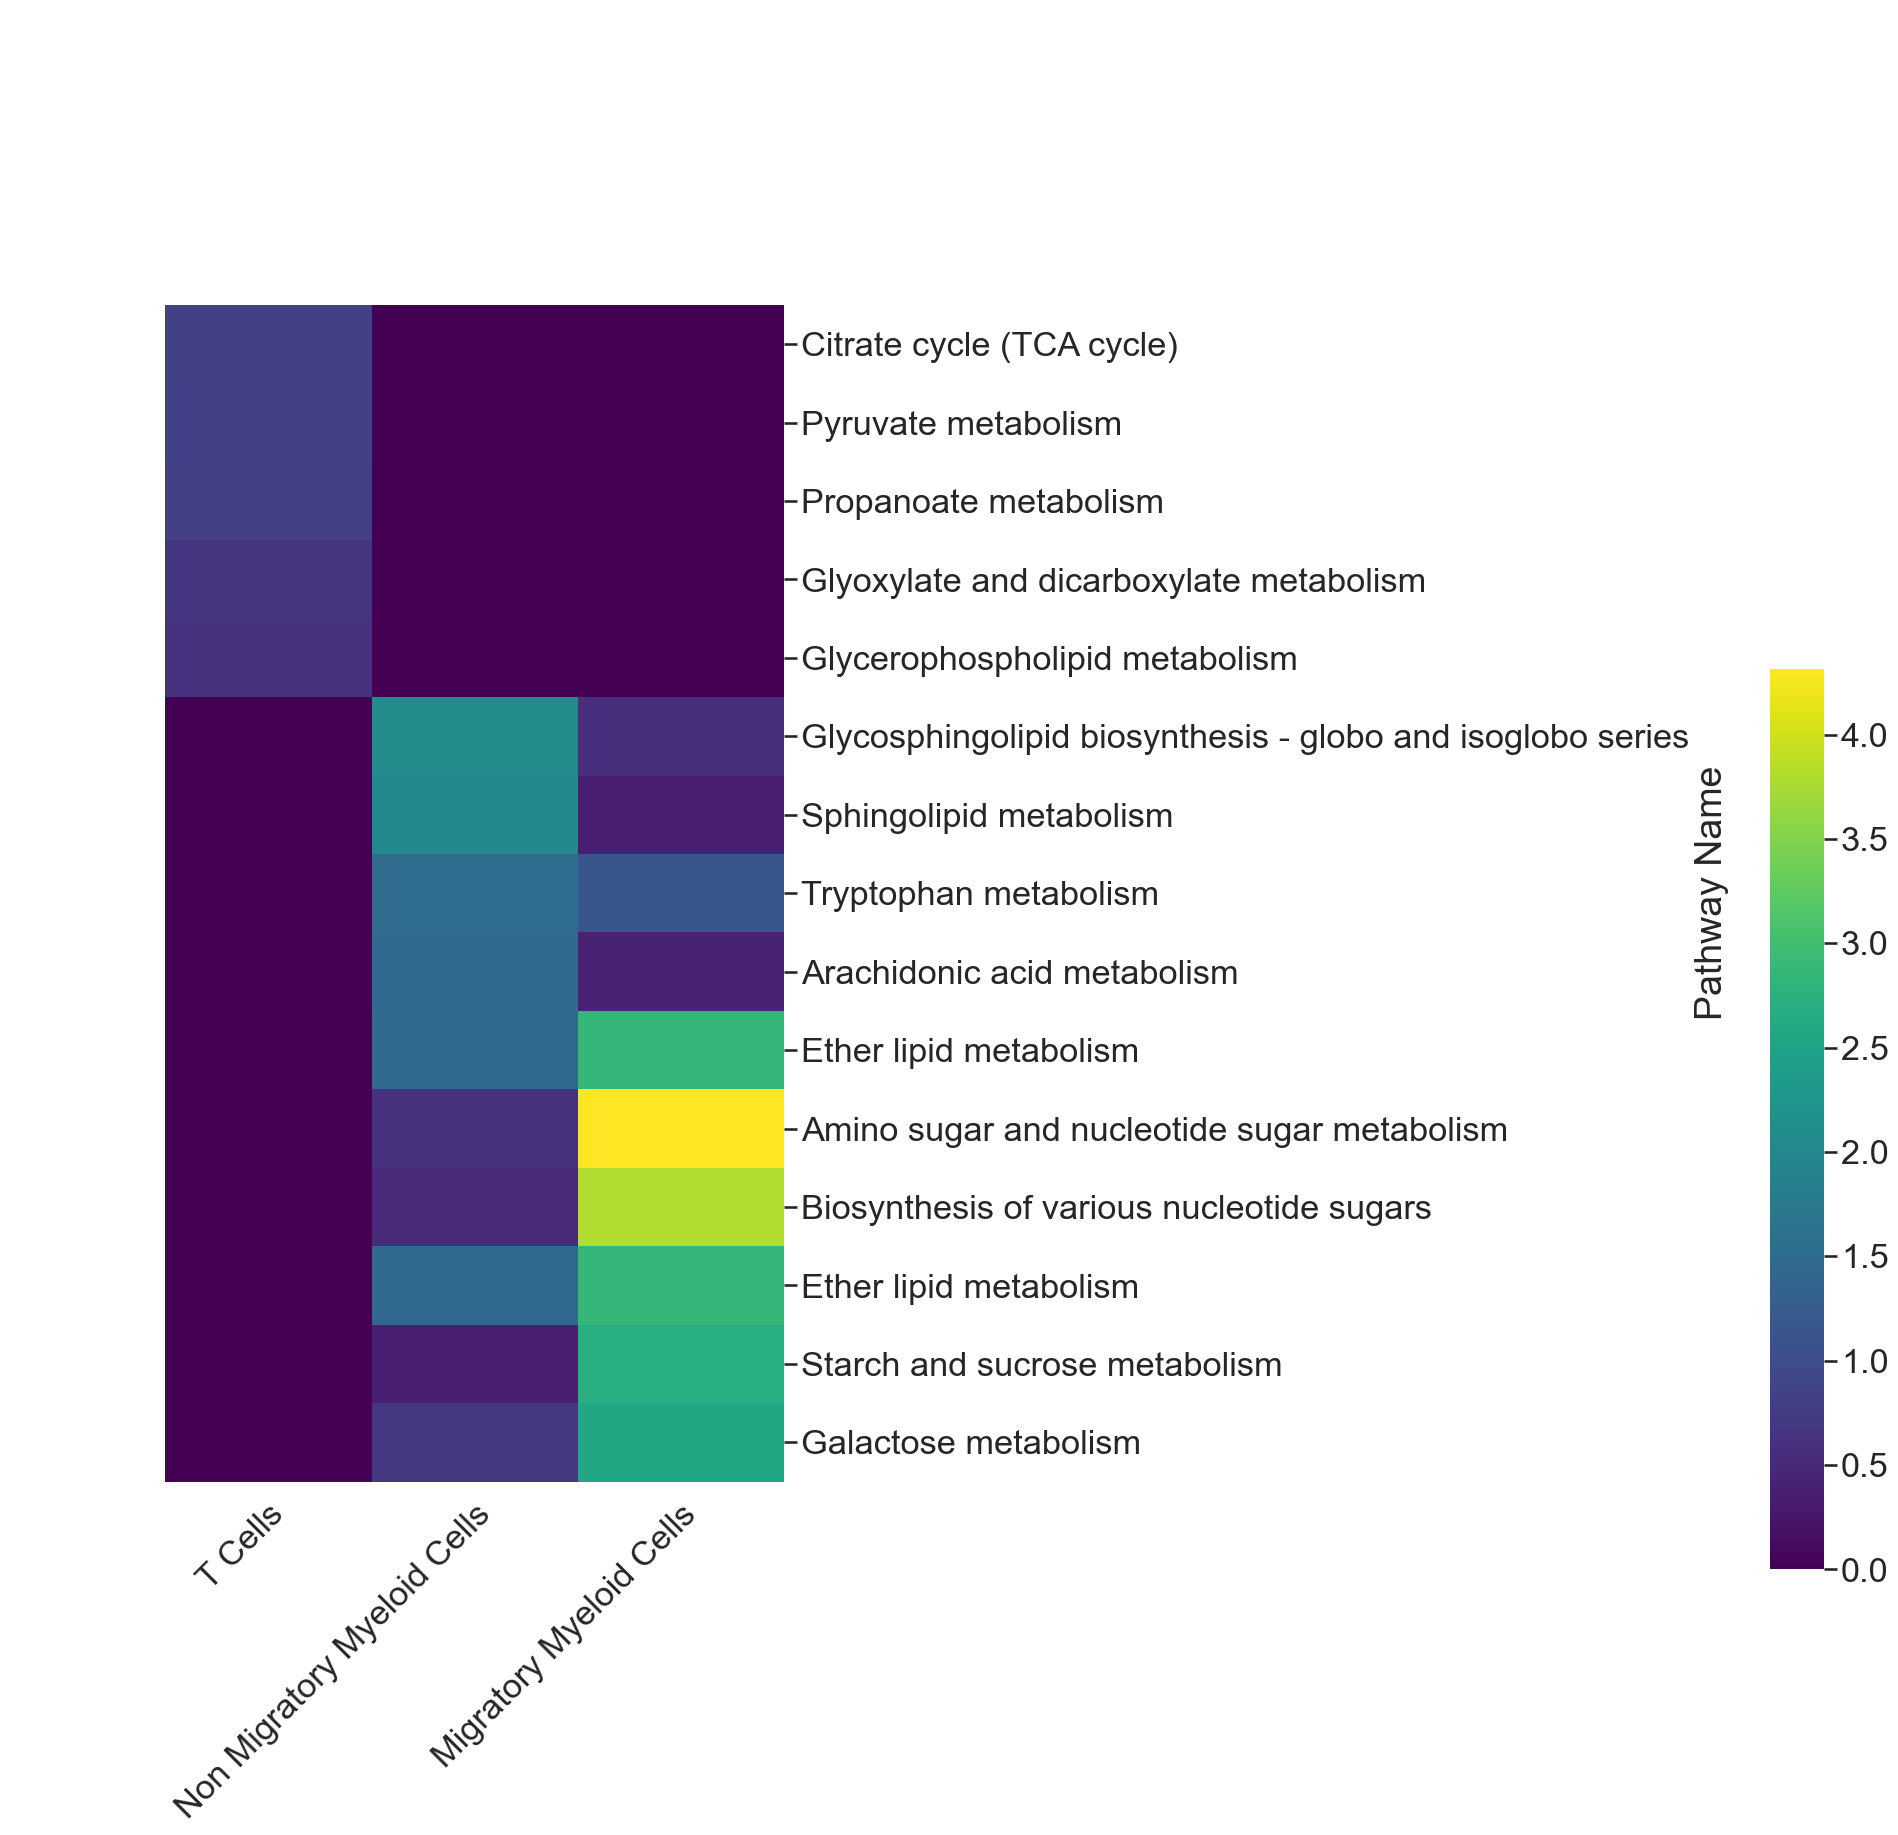

In [28]:
temp = enrich_df_concat[[f"cluster_{i}_cohens_d" for i in cluster_ids]].copy()
temp = temp.loc[top_pathways]

pval_mat = enrich_df_concat[[f"cluster_{i}_adjusted_pval" for i in cluster_ids]].copy()
pval_mat = pval_mat.loc[top_pathways]

new_cols = [cluster_labels.get(str(i), f"Cluster {i}") for i in cluster_ids]
temp.columns = new_cols
pval_mat.columns = new_cols

sns.set_context("talk", font_scale=1.5)

g = sns.clustermap(
    temp,
    cmap="viridis",
    col_cluster=False,
    row_cluster=False,
    figsize=(18, 20),
    vmin=0
)

plt.setp(
    g.ax_heatmap.get_xticklabels(),
    rotation=45,
    ha="right",
    rotation_mode="anchor"
)

g.cax.set_position([1.0, .2, .03, .45])

## Inter Cell Type Metabolic Difference Analysis

### Non Migratory vs Migratory Myeloid Cells
Across both the reaction-level and pathway-level analyses, we notice that **migratory and non-migratory myeloid cells exhibit strong metabolic differences across multiple reactions and pathways.**

To better understand this observation, we now perform a more focused comparison between **migratory and non-migratory myeloid cells**, examining the reactions and pathways that most strongly distinguish these two populations.

Using a Wilcoxon rank-sum test, we identify both **differentially active reactions** and **enriched metabolic pathways** between these two populations. We then filter pathways to retain biologically meaningful KEGG pathways and map each reaction to its associated pathways.

Finally, we visualize the reactions contributing to the most strongly enriched pathways. Each point represents a reaction associated with a pathway, and the effect size (Cohen’s d) indicates whether the reaction is relatively more active in migratory or non-migratory myeloid cells.

/Users/adelinac/opt/anaconda3/envs/mern_2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


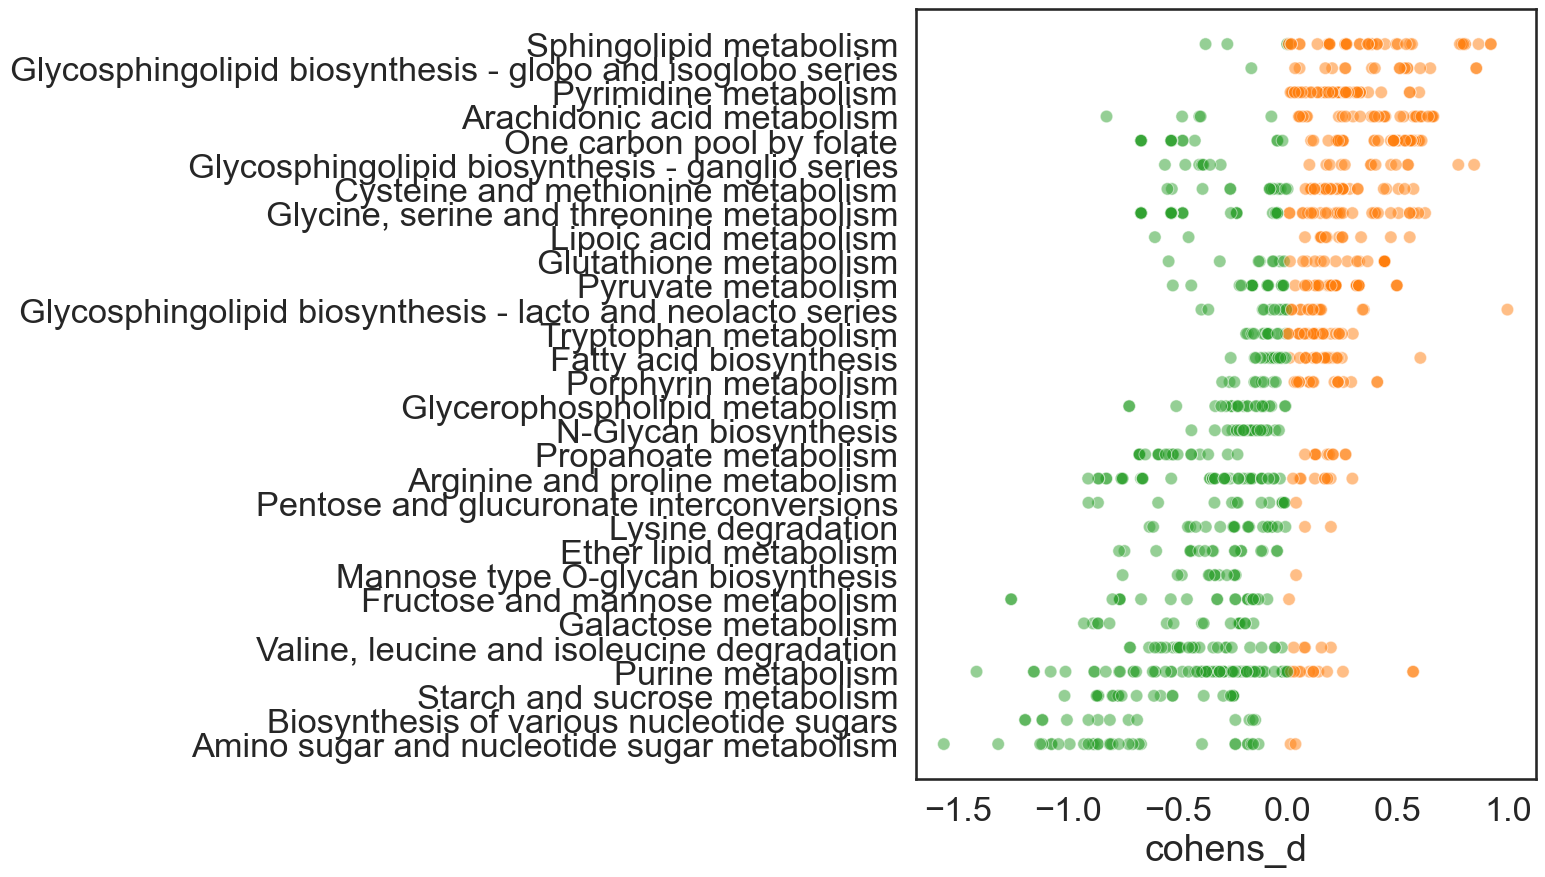

In [29]:
cluster_a = 1 # non migratory cells
cluster_b = 2 # migratory cells

up_cells = rna[rna.obs['met_leiden']==f'{cluster_a}',:].obs_names
down_cells = rna[rna.obs['met_leiden'] == f'{cluster_b}', :].obs_names
enrich_df = mern_support.wilcoxon_test(pathway_scores, up_cells, down_cells)
rxn_de_df_2 = mern_support.wilcoxon_test(enzyme_acts.T, up_cells, down_cells)
rxn_de_df_2['-log10(adj_pval)'] = -np.log10(rxn_de_df_2['adjusted_pval'])
temp = rna.uns['Reaction Info'].copy()
rxn_de_df_info_2 = temp.join(rxn_de_df_2)
rxn_de_df_info_2['edge_size'] = [3 if p < 0.05 else 2 for p in rxn_de_df_info_2['adjusted_pval']]

keep_pathways = []
names = []
for pathway in enrich_df.index:
    in_mouse = True if pathway in mouse_pathways else False
    not_general = True if not pathway.startswith('rn01') else False
    meets_cutoff = True if len(pathway_rxns[pathway]) > 10 else False
    if in_mouse and not_general and meets_cutoff:
        keep_pathways.append(pathway)
        names.append(pathway_names[pathway])
keep_pathways
enrich_df = enrich_df.loc[keep_pathways]
enrich_df['Pathway Name'] = names
enrich_df['Pathway ID'] = enrich_df.index
enrich_df.index = enrich_df['Pathway Name']

df_exploded = rxn_de_df_info_2.copy()

df_exploded['cluster_dir'] = np.where(
    df_exploded['cohens_d'] >= 0, 'up_cells', 'down_cells'
)

# If both 'Pathways' and 'Pathway Names' exist, explode them together with a 1:1 mapping
if 'Pathway Names' in df_exploded.columns:
    df_exploded[['Pathways', 'Pathway Names']] = df_exploded[['Pathways', 'Pathway Names']].apply(
        lambda col: col.str.split(';'))
    # zip -> create tuples, then expand each row to list of tuples, then explode, then split back to columns
    df_exploded = df_exploded.assign(
        pathway_tuple=list(
            df_exploded[['Pathways', 'Pathway Names']].apply(lambda row: list(zip(
                [x.strip() for x in row['Pathways']],
                [x.strip() for x in row['Pathway Names']]
            )), axis=1))
    )
    df_exploded = df_exploded.explode('pathway_tuple')
    # Unpack tuple to Pathways and Pathway Names
    df_exploded['Pathways'] = df_exploded['pathway_tuple'].apply(lambda x: x[0] if isinstance(x, tuple) else x)
    df_exploded['Pathway Names'] = df_exploded['pathway_tuple'].apply(lambda x: x[1] if isinstance(x, tuple) else x)
    df_exploded = df_exploded.drop(columns=['pathway_tuple'])
else:
    df_exploded['Pathways'] = df_exploded['Pathways'].str.split(';')
    df_exploded = df_exploded.explode('Pathways')
    df_exploded['Pathways'] = df_exploded['Pathways'].str.strip()

keep_pathways = []
names = []
for pathway in df_exploded['Pathways']:
    in_mouse = True if pathway in mouse_pathways else False
    not_general = True if not pathway.startswith('rn01') else False
    meets_cutoff = True if len(pathway_rxns[pathway]) > 10 else False
    if in_mouse and not_general and meets_cutoff:
        keep_pathways.append(pathway)
        names.append(pathway_names[pathway])
df_exploded = df_exploded[df_exploded['Pathways'].isin(keep_pathways)]
df_exploded['color'] = ['red' if x > 0 else 'blue' for x in df_exploded['cohens_d']]

try:
    palette = {'up_cells': rna.uns["met_leiden_colors"][cluster_a], 'down_cells': rna.uns["met_leiden_colors"][cluster_b]}
except:
    palette = None

sorted_indices = enrich_df.sort_values(by='cohens_d', ascending=False).index
top_15 = sorted_indices[:15]
bottom_15 = sorted_indices[-15:]
sorted_pathways = top_15.append(bottom_15)
temp = df_exploded[df_exploded['Pathway Names'].isin(sorted_pathways)]
plt.figure(figsize=(8, 10))  # Make the plot taller
ax = sns.scatterplot(
    data=temp,
    x='cohens_d',
    y=pd.Categorical(temp['Pathway Names'], categories=sorted_pathways, ordered=True),
    hue='cluster_dir',
    palette=palette,
    alpha=0.5
)

ax.legend_.remove()
plt.show()

To further interpret the reaction-level differences between migratory and non-migratory myeloid cells, we visualize reactions from key **energy metabolism pathways**, including glycolysis and the TCA cycle.

Reactions belonging to these pathways are highlighted directly on the metabolic network and colored by their effect size (Cohen’s *d*), indicating whether they are relatively more active in migratory or non-migratory cells. Edge thickness reflects statistical significance, while a custom color scale highlights reactions enriched in each population.

This network view helps illustrate how core energy metabolism pathways contribute to the metabolic divergence between the two myeloid cell populations.

In [30]:
custom_scale = [
    [0.0, rna.uns["met_leiden_colors"][cluster_b]],
    [0.5, "#F7F7F7"],
    [1.0, rna.uns["met_leiden_colors"][cluster_a]],
]
custom = []
pathways = ['rn00010', 'rn00020']
for rxn in rxn_de_df_info_2.index:
    for pathway in rxn_de_df_info_2.loc[rxn, 'Pathways'].split(';'):
        if pathway in pathways:
            custom.append(rxn)
custom += ['rn:R11945',
'rn:R13223',
'rn:R13224',
'rn:R02161',
'rn:R00081',
'rn:R00086 rn:R00331']

mern_support.custom_pathway_plot(custom, dataset, 'rna', user_labels=rxn_de_df_info_2['cohens_d'],color_scale=custom_scale, edge_sizes=rxn_de_df_info_2['edge_size'], show_node_labels=False).show()

### T Cells vs Myeloid Cells
In addition to differences within the myeloid lineage, we can also use MeRN to examine broader metabolic differences between major immune cell types.

Here, we compare **T cells and myeloid cells** to identify metabolic programs that distinguish these two immune lineages. Using the reaction- and pathway-level signals inferred by MeRN, we investigate which metabolic processes are enriched in each group.

/Users/adelinac/opt/anaconda3/envs/mern_2/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


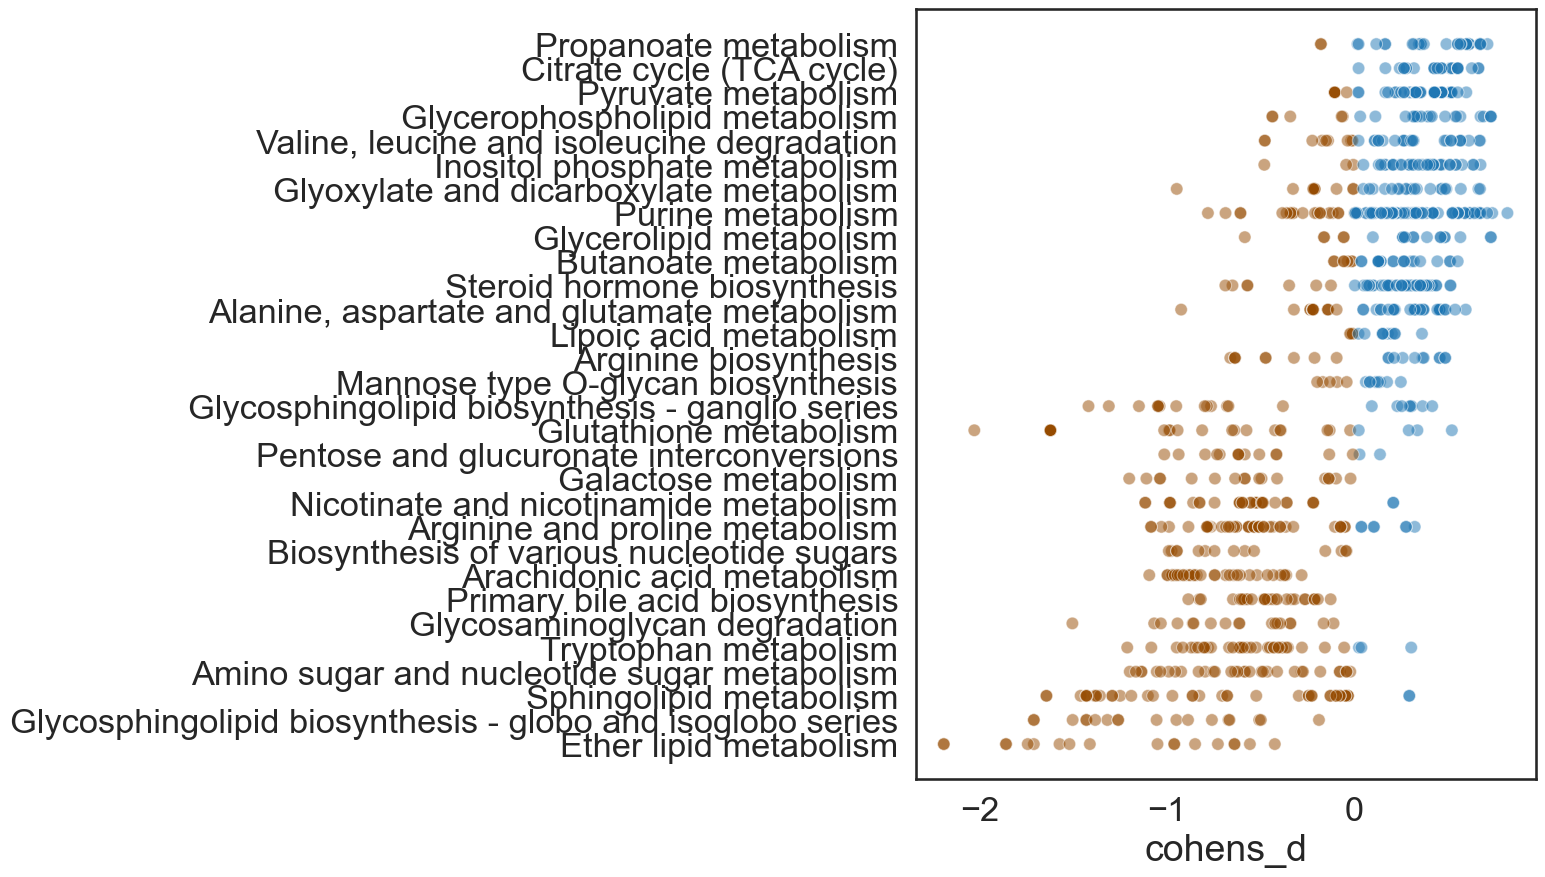

In [31]:
cluster_a = 0
cluster_b = 1 # non migratory myeloid cells
cluster_c = 2 # migratory myeloid cells
up_cells = rna[rna.obs['met_leiden']==f'{cluster_a}',:].obs_names
down_cells_1 = rna[rna.obs['met_leiden'] == f'{cluster_b}', :].obs_names
down_cells_2 = rna[rna.obs['met_leiden'] == f'{cluster_c}', :].obs_names
down_cells = down_cells_1.append(down_cells_2)
down_cells = rna[rna.obs['met_leiden'] == f'{cluster_b}', :].obs_names
enrich_df = mern_support.wilcoxon_test(pathway_scores, up_cells, down_cells)
rxn_de_df_2 = mern_support.wilcoxon_test(enzyme_acts.T, up_cells, down_cells)
rxn_de_df_2['-log10(adj_pval)'] = -np.log10(rxn_de_df_2['adjusted_pval'])
temp = rna.uns['Reaction Info'].copy()
rxn_de_df_info_2 = temp.join(rxn_de_df_2)
rxn_de_df_info_2['edge_size'] = [3 if p < 0.05 else 2 for p in rxn_de_df_info_2['adjusted_pval']]

keep_pathways = []
names = []
for pathway in enrich_df.index:
    in_mouse = True if pathway in mouse_pathways else False
    not_general = True if not pathway.startswith('rn01') else False
    meets_cutoff = True if len(pathway_rxns[pathway]) > 10 else False
    if in_mouse and not_general and meets_cutoff:
        keep_pathways.append(pathway)
        names.append(pathway_names[pathway])
keep_pathways
enrich_df = enrich_df.loc[keep_pathways]
enrich_df['Pathway Name'] = names
enrich_df['Pathway ID'] = enrich_df.index
enrich_df.index = enrich_df['Pathway Name']

df_exploded = rxn_de_df_info_2.copy()

df_exploded['cluster_dir'] = np.where(
    df_exploded['cohens_d'] >= 0, 'up_cells', 'down_cells'
)

# If both 'Pathways' and 'Pathway Names' exist, explode them together with a 1:1 mapping
if 'Pathway Names' in df_exploded.columns:
    df_exploded[['Pathways', 'Pathway Names']] = df_exploded[['Pathways', 'Pathway Names']].apply(
        lambda col: col.str.split(';'))
    # zip -> create tuples, then expand each row to list of tuples, then explode, then split back to columns
    df_exploded = df_exploded.assign(
        pathway_tuple=list(
            df_exploded[['Pathways', 'Pathway Names']].apply(lambda row: list(zip(
                [x.strip() for x in row['Pathways']],
                [x.strip() for x in row['Pathway Names']]
            )), axis=1))
    )
    df_exploded = df_exploded.explode('pathway_tuple')
    # Unpack tuple to Pathways and Pathway Names
    df_exploded['Pathways'] = df_exploded['pathway_tuple'].apply(lambda x: x[0] if isinstance(x, tuple) else x)
    df_exploded['Pathway Names'] = df_exploded['pathway_tuple'].apply(lambda x: x[1] if isinstance(x, tuple) else x)
    df_exploded = df_exploded.drop(columns=['pathway_tuple'])
else:
    df_exploded['Pathways'] = df_exploded['Pathways'].str.split(';')
    df_exploded = df_exploded.explode('Pathways')
    df_exploded['Pathways'] = df_exploded['Pathways'].str.strip()

keep_pathways = []
names = []
for pathway in df_exploded['Pathways']:
    in_mouse = True if pathway in mouse_pathways else False
    not_general = True if not pathway.startswith('rn01') else False
    meets_cutoff = True if len(pathway_rxns[pathway]) > 10 else False
    if in_mouse and not_general and meets_cutoff:
        keep_pathways.append(pathway)
        names.append(pathway_names[pathway])
df_exploded = df_exploded[df_exploded['Pathways'].isin(keep_pathways)]
df_exploded['color'] = ['red' if x > 0 else 'blue' for x in df_exploded['cohens_d']]

try:
    palette = {'up_cells': rna.uns["met_leiden_colors"][cluster_a], 'down_cells': "#964B00"}
except:
    palette = None

sorted_indices = enrich_df.sort_values(by='cohens_d', ascending=False).index
top_15 = sorted_indices[:15]
bottom_15 = sorted_indices[-15:]
sorted_pathways = top_15.append(bottom_15)
temp = df_exploded[df_exploded['Pathway Names'].isin(sorted_pathways)]
plt.figure(figsize=(8, 10))  # Make the plot taller
ax = sns.scatterplot(
    data=temp,
    x='cohens_d',
    y=pd.Categorical(temp['Pathway Names'], categories=sorted_pathways, ordered=True),
    hue='cluster_dir',
    palette=palette,
    alpha=0.5
)

ax.legend_.remove()
plt.show()


In [32]:
custom_scale = [
    [0.0, "#964B00"],
    [0.5, "#F7F7F7"],
    [1.0, rna.uns["met_leiden_colors"][cluster_a]],
]
custom = []
pathways = ['rn00010', 'rn00020']
for rxn in rxn_de_df_info_2.index:
    for pathway in rxn_de_df_info_2.loc[rxn, 'Pathways'].split(';'):
        if pathway in pathways:
            custom.append(rxn)
custom += ['rn:R11945',
'rn:R13223',
'rn:R13224',
'rn:R02161',
'rn:R00081',
'rn:R00086 rn:R00331']

mern_support.custom_pathway_plot(custom, dataset, 'rna', user_labels=rxn_de_df_info_2['cohens_d'],color_scale=custom_scale, edge_sizes=rxn_de_df_info_2['edge_size'], show_node_labels=False).show()